# 10 -- Modern Pipeline Evaluation, Calibration, and Uncertainty Examples

This notebook evaluates the EfficientNet-B0 model trained in notebook 09.

It produces:

- ROC/AUC;
- confusion matrices for MAP threshold 0.5 and cost-sensitive threshold 1/6;
- reliability diagrams and ECE;
- temperature scaling fitted on validation logits only;
- uncertainty/failure examples for qualitative discussion.


In [1]:
import os
import sys
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
from torchvision import transforms 

# Robust project discovery: supports both
#   parent/skin_lesion/src/config.py
# and
#   project/src/config.py
_cwd = Path(os.getcwd()).resolve()
SRC_DIR = None
PROJECT_DIR = None
for _root in [_cwd, *_cwd.parents]:
    cand = _root / "skin_lesion" / "src" / "config.py"
    if cand.exists():
        SRC_DIR = cand.parent
        PROJECT_DIR = SRC_DIR.parent
        break
    cand = _root / "src" / "config.py"
    if cand.exists():
        SRC_DIR = cand.parent
        PROJECT_DIR = SRC_DIR.parent
        break

if SRC_DIR is None:
    raise FileNotFoundError(
        "Could not find src/config.py. Run this notebook from inside the project "
        "or from the parent folder containing skin_lesion/."
    )

sys.path.insert(0, str(SRC_DIR))

from config import SEED, COST_FN, COST_FP, MC_DROPOUT_T

# Use paths relative to the detected project folder. This avoids path issues
# if the zip is extracted either as skin_lesion/ or as the project root.
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
TABLES_DIR = PROJECT_DIR / "results" / "tables"
MODELS_DIR = PROJECT_DIR / "results" / "models"

for d in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"RAW_DIR       : {RAW_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"FIGURES_DIR   : {FIGURES_DIR}")
print(f"TABLES_DIR    : {TABLES_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import minimize_scalar

from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss,
)


PROJECT_DIR   : C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion
RAW_DIR       : C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\data\raw
PROCESSED_DIR : C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\data\processed
FIGURES_DIR   : C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\figures
TABLES_DIR    : C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\tables
MODELS_DIR    : C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\models


## 1 -- Load EfficientNet predictions


In [2]:
val_path = PROCESSED_DIR / "efficientnet_predictions_val.csv"
test_path = PROCESSED_DIR / "efficientnet_predictions_test.csv"

if not val_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        "Missing EfficientNet predictions. Run 09_efficientnet_training.ipynb first."
    )

val_pred = pd.read_csv(val_path)
test_pred = pd.read_csv(test_path)

for df in [val_pred, test_pred]:
    df["image_id"] = df["image_id"].astype(str)
    df["label"] = df["label"].astype(int)

print(f"Validation predictions: {val_pred.shape}")
print(f"Test predictions      : {test_pred.shape}")
print(test_pred.head())


Validation predictions: (445, 5)
Test predictions      : (446, 5)
       image_id split  label     logit  prob_melanoma
0  ISIC_0026993  test      1  4.008661       0.982166
1  ISIC_0029512  test      1 -0.078670       0.480343
2  ISIC_0027872  test      1  0.787269       0.687245
3  ISIC_0025303  test      1  0.806623       0.691390
4  ISIC_0030129  test      1  0.673858       0.662366


## 2 -- Metrics helpers


In [3]:
THRESH_MAP = 0.5
THRESH_COST = COST_FP / (COST_FP + COST_FN)  # = 1/6 when FN=5 and FP=1
N_BINS = 15

print(f"MAP threshold            : {THRESH_MAP:.6f}")
print(f"Cost-sensitive threshold : {THRESH_COST:.6f}")


def binary_metrics(labels, probs, threshold, model="efficientnet_b0", calibration="none"):
    labels = np.asarray(labels).astype(int)
    probs = np.asarray(probs).astype(float)
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0, 1]).ravel()
    return {
        "model": model,
        "calibration": calibration,
        "threshold": threshold,
        "accuracy": accuracy_score(labels, pred),
        "sensitivity": recall_score(labels, pred, pos_label=1, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(labels, pred, pos_label=1, zero_division=0),
        "f1": f1_score(labels, pred, pos_label=1, zero_division=0),
        "FN": int(fn),
        "FP": int(fp),
        "TP": int(tp),
        "TN": int(tn),
        "total_cost": int(COST_FN * fn + COST_FP * fp),
    }


def reliability_stats(probs, labels, n_bins=15):
    labels = np.asarray(labels).astype(int)
    probs = np.asarray(probs).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    bin_conf = np.full(n_bins, np.nan)
    bin_acc = np.full(n_bins, np.nan)
    bin_counts = np.zeros(n_bins, dtype=int)
    for m in range(n_bins):
        mask = (probs >= bins[m]) & (probs < bins[m + 1])
        if m == n_bins - 1:
            mask |= probs == bins[m + 1]
        if mask.sum() > 0:
            bin_conf[m] = probs[mask].mean()
            bin_acc[m] = labels[mask].mean()
            bin_counts[m] = mask.sum()
    return centers, bin_conf, bin_acc, bin_counts


def expected_calibration_error(probs, labels, n_bins=15):
    _, bin_conf, bin_acc, bin_counts = reliability_stats(probs, labels, n_bins)
    valid = ~np.isnan(bin_conf)
    n = len(labels)
    return float(np.sum((bin_counts[valid] / n) * np.abs(bin_acc[valid] - bin_conf[valid])))


def plot_reliability(ax, probs, labels, title, n_bins=15):
    centers, bin_conf, bin_acc, bin_counts = reliability_stats(probs, labels, n_bins)
    valid = ~np.isnan(bin_conf)
    width = 1.0 / n_bins * 0.85
    ax.bar(centers[valid], bin_acc[valid], width=width, alpha=0.7, label="Fraction positives")
    ax.plot([0, 1], [0, 1], "--", lw=1.5, label="Perfect")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction positives")
    ax.set_title(f"{title}\nECE = {expected_calibration_error(probs, labels, n_bins):.4f}")
    ax.grid(True, linestyle=":")
    ax.legend(fontsize=8)


MAP threshold            : 0.500000
Cost-sensitive threshold : 0.166667


## 3 -- ROC curve and raw-threshold decisions


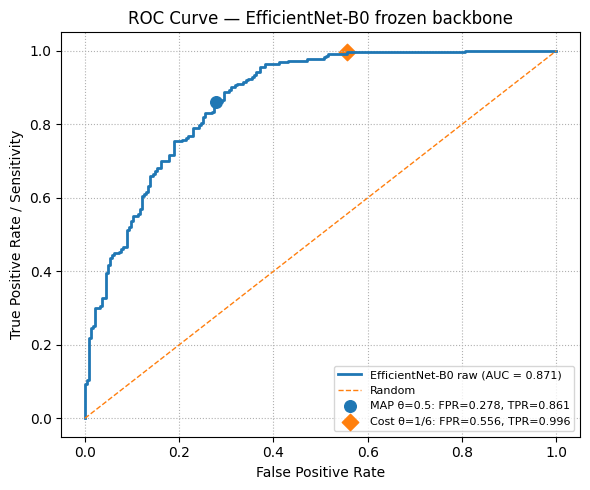

Raw EfficientNet test AUC = 0.8712
          model calibration  threshold  accuracy  sensitivity  specificity  precision       f1  FN  FP  TP  TN  total_cost
efficientnet_b0        none   0.500000  0.789238     0.856502     0.721973   0.754941 0.802521  32  62 191 161         222
efficientnet_b0        none   0.166667  0.719731     0.995516     0.443946   0.641618 0.780316   1 124 222  99         129


In [4]:
y_test = test_pred["label"].to_numpy(dtype=int)
probs_raw = test_pred["prob_melanoma"].to_numpy(dtype=float)
logits_test = test_pred["logit"].to_numpy(dtype=float)

fpr, tpr, roc_thresholds = roc_curve(y_test, probs_raw)
auc_raw = roc_auc_score(y_test, probs_raw)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"EfficientNet-B0 raw (AUC = {auc_raw:.3f})")
ax.plot([0, 1], [0, 1], "--", lw=1, label="Random")
for th, name, marker in [(THRESH_MAP, "MAP θ=0.5", "o"), (THRESH_COST, "Cost θ=1/6", "D")]:
    idx = np.argmin(np.abs(roc_thresholds - th))
    ax.scatter(fpr[idx], tpr[idx], s=70, marker=marker, label=f"{name}: FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Sensitivity")
ax.set_title("ROC Curve — EfficientNet-B0 frozen backbone")
ax.grid(True, linestyle=":")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Raw EfficientNet test AUC = {auc_raw:.4f}")

rows_raw = [
    binary_metrics(y_test, probs_raw, THRESH_MAP,  calibration="none"),
    binary_metrics(y_test, probs_raw, THRESH_COST, calibration="none"),
]
raw_decisions = pd.DataFrame(rows_raw)
print(raw_decisions.to_string(index=False))


## 4 -- Raw calibration: reliability diagram and ECE


ECE raw EfficientNet = 0.0484


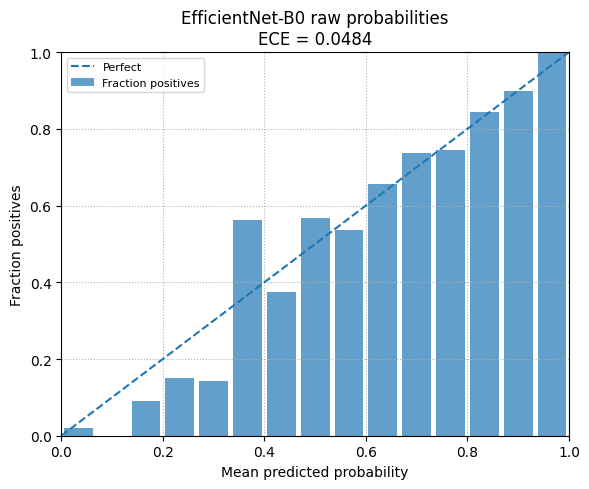

In [5]:
ece_raw = expected_calibration_error(probs_raw, y_test, N_BINS)
print(f"ECE raw EfficientNet = {ece_raw:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
plot_reliability(ax, probs_raw, y_test, "EfficientNet-B0 raw probabilities", N_BINS)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_reliability_raw.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 -- Temperature scaling

Temperature is fitted on validation logits only. The test set is used only after `T` has been selected.


In [6]:
y_val = val_pred["label"].to_numpy(dtype=int)
logits_val = val_pred["logit"].to_numpy(dtype=float)


def sigmoid_stable(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def nll_temperature(T, logits, labels):
    probs = sigmoid_stable(logits / T)
    eps = 1e-15
    probs = np.clip(probs, eps, 1 - eps)
    return -np.mean(labels * np.log(probs) + (1 - labels) * np.log(1 - probs))

result = minimize_scalar(
    nll_temperature,
    args=(logits_val, y_val),
    bounds=(0.05, 20.0),
    method="bounded",
)
T_opt = float(result.x)
print(f"Optimal temperature T = {T_opt:.4f}")
print(f"Validation NLL before scaling: {nll_temperature(1.0, logits_val, y_val):.4f}")
print(f"Validation NLL after scaling : {nll_temperature(T_opt, logits_val, y_val):.4f}")

probs_cal = sigmoid_stable(logits_test / T_opt)
ece_cal = expected_calibration_error(probs_cal, y_test, N_BINS)
auc_cal = roc_auc_score(y_test, probs_cal)

print(f"Test AUC raw/calibrated: {auc_raw:.4f} / {auc_cal:.4f}")
print(f"Test ECE raw/calibrated: {ece_raw:.4f} / {ece_cal:.4f}")


Optimal temperature T = 1.2702
Validation NLL before scaling: 0.5454
Validation NLL after scaling : 0.5388
Test AUC raw/calibrated: 0.8712 / 0.8712
Test ECE raw/calibrated: 0.0484 / 0.0705


## 6 -- Calibrated reliability and decision table


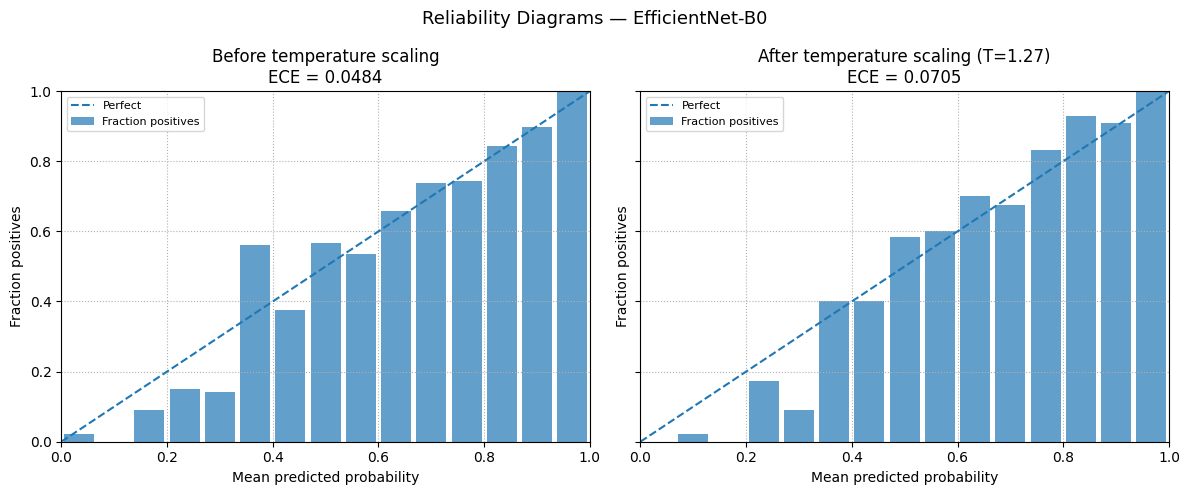

          model         calibration  threshold  accuracy  sensitivity  specificity  precision     f1  FN  FP  TP  TN  total_cost
efficientnet_b0                none   0.500000    0.7892       0.8565       0.7220     0.7549 0.8025  32  62 191 161         222
efficientnet_b0                none   0.166667    0.7197       0.9955       0.4439     0.6416 0.7803   1 124 222  99         129
efficientnet_b0 temperature_scaling   0.500000    0.7892       0.8565       0.7220     0.7549 0.8025  32  62 191 161         222
efficientnet_b0 temperature_scaling   0.166667    0.6816       0.9955       0.3677     0.6116 0.7577   1 141 222  82         146
Saved: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\tables\efficientnet_decision_comparison.csv
          model         calibration      T    auc    ece  n_bins
efficientnet_b0                none 1.0000 0.8712 0.0484      15
efficientnet_b0 temperature_scaling 1.2702 0.8712 0.0705      15
Saved: C:\Users\minef\Downloads\Skin\ski

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
plot_reliability(axes[0], probs_raw, y_test, "Before temperature scaling", N_BINS)
plot_reliability(axes[1], probs_cal, y_test, f"After temperature scaling (T={T_opt:.2f})", N_BINS)
fig.suptitle("Reliability Diagrams — EfficientNet-B0", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_reliability_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()

rows = []
for calibration, probs in [("none", probs_raw), ("temperature_scaling", probs_cal)]:
    rows.append(binary_metrics(y_test, probs, THRESH_MAP, calibration=calibration))
    rows.append(binary_metrics(y_test, probs, THRESH_COST, calibration=calibration))

decision_df = pd.DataFrame(rows)
for col in ["accuracy", "sensitivity", "specificity", "precision", "f1"]:
    decision_df[col] = decision_df[col].round(4)
decision_df["threshold"] = decision_df["threshold"].round(6)
print(decision_df.to_string(index=False))

out_dec = TABLES_DIR / "efficientnet_decision_comparison.csv"
decision_df.to_csv(out_dec, index=False)
print(f"Saved: {out_dec}")

cal_df = pd.DataFrame([
    {"model": "efficientnet_b0", "calibration": "none", "T": 1.0, "auc": auc_raw, "ece": ece_raw, "n_bins": N_BINS},
    {"model": "efficientnet_b0", "calibration": "temperature_scaling", "T": T_opt, "auc": auc_cal, "ece": ece_cal, "n_bins": N_BINS},
])
cal_df[["auc", "ece", "T"]] = cal_df[["auc", "ece", "T"]].round(4)
print(cal_df.to_string(index=False))
out_cal = TABLES_DIR / "efficientnet_calibration_summary.csv"
cal_df.to_csv(out_cal, index=False)
print(f"Saved: {out_cal}")

# Save calibrated test predictions.
test_pred_cal = test_pred.copy()
test_pred_cal["prob_melanoma_calibrated"] = probs_cal
test_pred_cal["temperature"] = T_opt
test_pred_cal.to_csv(PROCESSED_DIR / "efficientnet_predictions_test_calibrated.csv", index=False)
print(f"Saved: {PROCESSED_DIR / 'efficientnet_predictions_test_calibrated.csv'}")


## 7 -- Minimal MC Dropout uncertainty

The EfficientNet backbone is kept in evaluation mode. Only the Dropout layer in the binary head is activated during inference.
This avoids updating BatchNorm statistics while still producing stochastic predictions.


In [8]:
# Minimal MC Dropout implementation.
# It uses the trained checkpoint from notebook 09 and runs T stochastic forward passes on the test set.

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device for MC Dropout: {DEVICE}")

# Same deterministic evaluation transform used in notebook 09.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Resolve image paths for the test images.
subset_path = PROCESSED_DIR / "balanced_subset.csv"
subset = pd.read_csv(subset_path)
subset["image_id"] = subset["image_id"].astype(str)

image_index = {p.stem: p for p in RAW_DIR.rglob("*.jpg")}

def resolve_image_path(row):
    p = row.get("image_path", None)
    if isinstance(p, str) and Path(p).exists():
        return p
    fallback = image_index.get(str(row["image_id"]))
    return str(fallback) if fallback is not None else None

subset["image_path_resolved"] = subset.apply(resolve_image_path, axis=1)

test_mc_input = test_pred_cal.merge(
    subset[["image_id", "image_path_resolved"]],
    on="image_id",
    how="left",
)
test_mc_input = test_mc_input.rename(columns={"image_path_resolved": "image_path"})

missing_paths = test_mc_input["image_path"].isna() | ~test_mc_input["image_path"].map(lambda p: Path(str(p)).exists())
if missing_paths.any():
    raise FileNotFoundError(
        f"Could not resolve image paths for {int(missing_paths.sum())} test images. "
        "Check RAW_DIR and balanced_subset.csv."
    )

class SkinLesionEvalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(float(row["label"]), dtype=torch.float32)
        return image, label, str(row["image_id"])


def build_efficientnet_b0_binary(dropout_p=0.20):
    # weights=None avoids downloading pretrained weights here.
    # The complete trained state_dict is loaded from the checkpoint below.
    model = tvm.efficientnet_b0(weights=None)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, 1),
    )
    return model


def enable_dropout_only(model):
    # Keep BatchNorm and the EfficientNet backbone in eval mode.
    # Activate only Dropout layers for stochastic inference.
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def mc_dropout_predict(model, loader, n_passes=30, temperature=1.0):
    all_probs = []
    labels_ref = None
    ids_ref = None

    for _ in range(n_passes):
        enable_dropout_only(model)
        probs_list, labels_list, ids_list = [], [], []

        for images, labels, image_ids in loader:
            images = images.to(DEVICE)
            logits = model(images).squeeze(1).detach().cpu().numpy()
            probs = sigmoid_stable(logits / temperature)

            probs_list.append(probs)
            labels_list.append(labels.numpy().astype(int))
            ids_list.extend(list(image_ids))

        probs_t = np.concatenate(probs_list)
        labels_t = np.concatenate(labels_list)
        ids_t = np.array(ids_list).astype(str)

        all_probs.append(probs_t)

        if labels_ref is None:
            labels_ref = labels_t
            ids_ref = ids_t
        else:
            assert np.array_equal(labels_ref, labels_t)
            assert np.array_equal(ids_ref, ids_t)

    probs_mc = np.stack(all_probs, axis=0)  # shape: [T, N]
    mean_prob = probs_mc.mean(axis=0)
    std_prob = probs_mc.std(axis=0)

    eps = 1e-12
    predictive_entropy = -(
        mean_prob * np.log(mean_prob + eps)
        + (1.0 - mean_prob) * np.log(1.0 - mean_prob + eps)
    )
    entropy_each_pass = -(
        probs_mc * np.log(probs_mc + eps)
        + (1.0 - probs_mc) * np.log(1.0 - probs_mc + eps)
    )
    expected_entropy = entropy_each_pass.mean(axis=0)
    mutual_information = predictive_entropy - expected_entropy

    return pd.DataFrame({
        "image_id": ids_ref,
        "label": labels_ref,
        "mc_mean_prob_melanoma": mean_prob,
        "mc_std_prob_melanoma": std_prob,
        "mc_predictive_entropy": predictive_entropy,
        "mc_normalized_entropy": predictive_entropy / np.log(2.0),
        "mc_expected_entropy": expected_entropy,
        "mc_mutual_information": mutual_information,
        "mc_margin_uncertainty": 1.0 - np.abs(2.0 * mean_prob - 1.0),
    })

# Load trained model.
ckpt_path = MODELS_DIR / "efficientnet_b0_frozen_head.pt"
if not ckpt_path.exists():
    raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}. Run notebook 09 first.")

try:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)

dropout_p = float(ckpt.get("dropout_p", 0.20))
mc_model = build_efficientnet_b0_binary(dropout_p=dropout_p).to(DEVICE)
mc_model.load_state_dict(ckpt["state_dict"])
mc_model.eval()

mc_loader = DataLoader(
    SkinLesionEvalDataset(test_mc_input, eval_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

n_mc = int(MC_DROPOUT_T)
print(f"MC Dropout passes: {n_mc}")

test_mc_summary = mc_dropout_predict(
    mc_model,
    mc_loader,
    n_passes=n_mc,
    temperature=T_opt,
)

test_mc_pred = test_pred_cal.merge(
    test_mc_summary,
    on=["image_id", "label"],
    how="left",
)

mc_probs = test_mc_pred["mc_mean_prob_melanoma"].to_numpy(dtype=float)
mc_auc = roc_auc_score(y_test, mc_probs)
mc_ece = expected_calibration_error(mc_probs, y_test, N_BINS)

print(f"MC Dropout test AUC: {mc_auc:.4f}")
print(f"MC Dropout test ECE: {mc_ece:.4f}")

mc_decision_df = pd.DataFrame([
    binary_metrics(y_test, mc_probs, THRESH_MAP,  model="efficientnet_b0_mc_dropout", calibration="temperature_scaled_mc_mean"),
    binary_metrics(y_test, mc_probs, THRESH_COST, model="efficientnet_b0_mc_dropout", calibration="temperature_scaled_mc_mean"),
])
mc_decision_df["auc"] = mc_auc
mc_decision_df["ece"] = mc_ece
for col in ["accuracy", "sensitivity", "specificity", "precision", "f1", "auc", "ece"]:
    mc_decision_df[col] = mc_decision_df[col].round(4)
mc_decision_df["threshold"] = mc_decision_df["threshold"].round(6)
print(mc_decision_df.to_string(index=False))

test_mc_path = PROCESSED_DIR / "efficientnet_predictions_test_mc_dropout.csv"
mc_table_path = TABLES_DIR / "efficientnet_mc_dropout_decision_comparison.csv"
test_mc_pred.to_csv(test_mc_path, index=False)
mc_decision_df.to_csv(mc_table_path, index=False)
print(f"Saved: {test_mc_path}")
print(f"Saved: {mc_table_path}")


Device for MC Dropout: cpu
MC Dropout passes: 30
MC Dropout test AUC: 0.8704
MC Dropout test ECE: 0.0711
                     model                calibration  threshold  accuracy  sensitivity  specificity  precision     f1  FN  FP  TP  TN  total_cost    auc    ece
efficientnet_b0_mc_dropout temperature_scaled_mc_mean   0.500000    0.7870       0.8565       0.7175     0.7520 0.8008  32  63 191 160         223 0.8704 0.0711
efficientnet_b0_mc_dropout temperature_scaled_mc_mean   0.166667    0.6816       0.9955       0.3677     0.6116 0.7577   1 141 222  82         146 0.8704 0.0711
Saved: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\data\processed\efficientnet_predictions_test_mc_dropout.csv
Saved: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\tables\efficientnet_mc_dropout_decision_comparison.csv


## 8 -- Confusion matrices


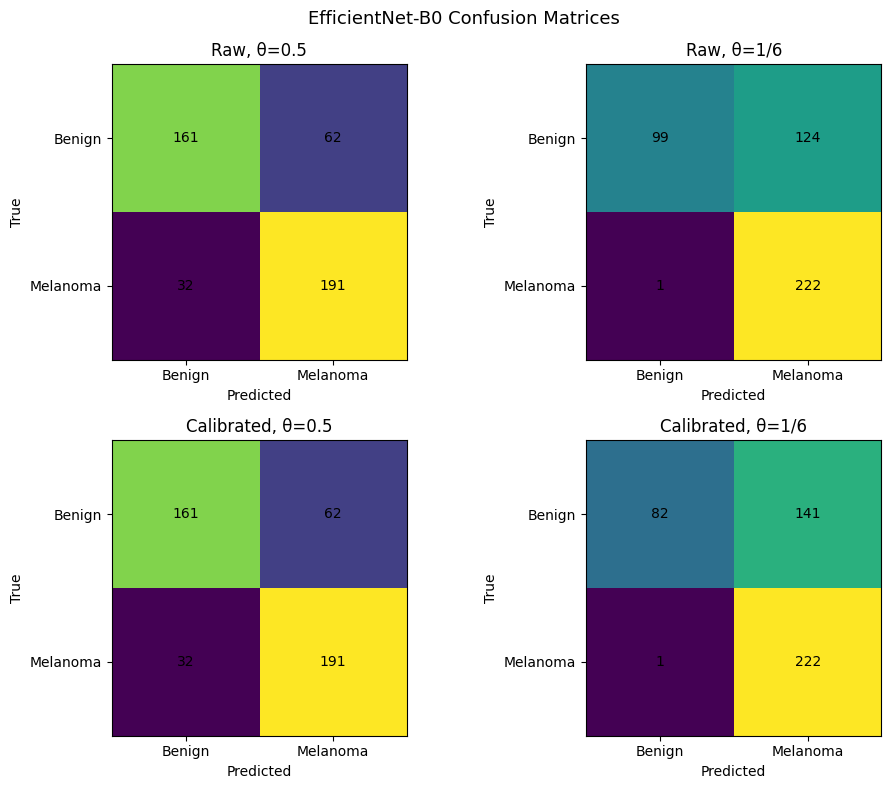

In [9]:
def plot_confusion(ax, labels, probs, threshold, title):
    pred = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, pred, labels=[0, 1])
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1], ["Benign", "Melanoma"])
    ax.set_yticks([0, 1], ["Benign", "Melanoma"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    return im

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_confusion(axes[0, 0], y_test, probs_raw, THRESH_MAP,  "Raw, θ=0.5")
plot_confusion(axes[0, 1], y_test, probs_raw, THRESH_COST, "Raw, θ=1/6")
plot_confusion(axes[1, 0], y_test, probs_cal, THRESH_MAP,  "Calibrated, θ=0.5")
plot_confusion(axes[1, 1], y_test, probs_cal, THRESH_COST, "Calibrated, θ=1/6")
fig.suptitle("EfficientNet-B0 Confusion Matrices", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 -- Qualitative MC Dropout uncertainty and failure examples

The examples below use the MC Dropout mean probability and uncertainty scores.
The most important uncertainty indicators are predictive entropy, probability standard deviation, and mutual information.


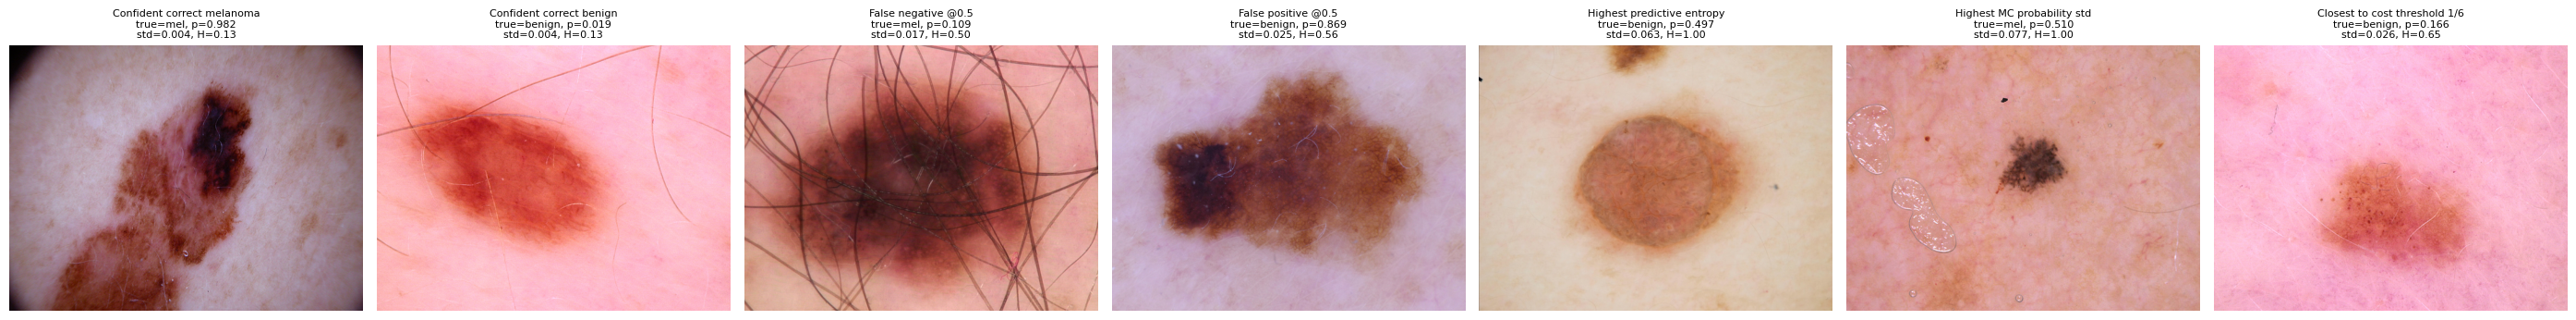

                 example_type     image_id  true_label  mc_mean_prob_melanoma  mc_std_prob_melanoma  mc_normalized_entropy  mc_mutual_information  pred_05  pred_cost
   Confident correct melanoma ISIC_0033479           1               0.981792              0.004064               0.131258               0.000456        1          1
     Confident correct benign ISIC_0026256           0               0.018554              0.004115               0.133242               0.000471        0          0
          False negative @0.5 ISIC_0026989           1               0.108502              0.017349               0.495381               0.001570        0          0
          False positive @0.5 ISIC_0028528           0               0.868694              0.025020               0.561009               0.002746        1          1
   Highest predictive entropy ISIC_0028183           0               0.497092              0.062565               0.999976               0.007897        0          1
   H

In [10]:
examples_df = test_mc_pred.merge(
    subset[["image_id", "image_path_resolved"]],
    on="image_id",
    how="left",
)

examples_df["p"] = examples_df["mc_mean_prob_melanoma"]
examples_df["pred_05"] = (examples_df["p"] >= THRESH_MAP).astype(int)
examples_df["pred_cost"] = (examples_df["p"] >= THRESH_COST).astype(int)
examples_df["distance_to_cost"] = (examples_df["p"] - THRESH_COST).abs()

selections = []

def add_example(name, df, sort_col=None, ascending=False):
    if len(df) == 0:
        print(f"No candidate for: {name}")
        return
    if sort_col is not None:
        row = df.sort_values(sort_col, ascending=ascending).iloc[0]
    else:
        row = df.iloc[0]
    selections.append((name, row))

add_example(
    "Confident correct melanoma",
    examples_df[(examples_df["label"] == 1) & (examples_df["pred_05"] == 1)],
    sort_col="p", ascending=False,
)
add_example(
    "Confident correct benign",
    examples_df[(examples_df["label"] == 0) & (examples_df["pred_05"] == 0)],
    sort_col="p", ascending=True,
)
add_example(
    "False negative @0.5",
    examples_df[(examples_df["label"] == 1) & (examples_df["pred_05"] == 0)],
    sort_col="p", ascending=True,
)
add_example(
    "False positive @0.5",
    examples_df[(examples_df["label"] == 0) & (examples_df["pred_05"] == 1)],
    sort_col="p", ascending=False,
)
add_example(
    "Highest predictive entropy",
    examples_df,
    sort_col="mc_predictive_entropy", ascending=False,
)
add_example(
    "Highest MC probability std",
    examples_df,
    sort_col="mc_std_prob_melanoma", ascending=False,
)
add_example(
    "Closest to cost threshold 1/6",
    examples_df,
    sort_col="distance_to_cost", ascending=True,
)

n = len(selections)
fig, axes = plt.subplots(1, n, figsize=(4 * max(n, 1), 4))
if n == 1:
    axes = [axes]

for ax, (title, row) in zip(axes, selections):
    img_path = row["image_path_resolved"]
    if isinstance(img_path, str) and Path(img_path).exists():
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "missing image", ha="center", va="center")

    true_name = "mel" if row["label"] == 1 else "benign"
    ax.set_title(
        f"{title}\n"
        f"true={true_name}, p={row['p']:.3f}\n"
        f"std={row['mc_std_prob_melanoma']:.3f}, H={row['mc_normalized_entropy']:.2f}",
        fontsize=8,
    )
    ax.axis("off")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_uncertainty_examples.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "modern_mc_dropout_uncertainty_examples.png", dpi=150, bbox_inches="tight")
plt.show()

examples_table = pd.DataFrame([
    {
        "example_type": name,
        "image_id": row["image_id"],
        "true_label": int(row["label"]),
        "mc_mean_prob_melanoma": float(row["p"]),
        "mc_std_prob_melanoma": float(row["mc_std_prob_melanoma"]),
        "mc_normalized_entropy": float(row["mc_normalized_entropy"]),
        "mc_mutual_information": float(row["mc_mutual_information"]),
        "pred_05": int(row["pred_05"]),
        "pred_cost": int(row["pred_cost"]),
    }
    for name, row in selections
])

examples_table.to_csv(TABLES_DIR / "efficientnet_uncertainty_examples.csv", index=False)
examples_table.to_csv(TABLES_DIR / "efficientnet_mc_dropout_uncertainty_examples.csv", index=False)
print(examples_table.to_string(index=False))
print(f"Saved examples table to: {TABLES_DIR / 'efficientnet_uncertainty_examples.csv'}")
